# DARTS Multi-Fidelity NAS — Time Series Example

End-to-end pipeline:
1. Generate a synthetic multi-component time series
2. Build windowed `DataLoader`s (train / val / test)
3. Initialise `DARTSTrainer`
4. Run `multi_fidelity_search`
5. Inspect the discovered architecture and final model metrics

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, TensorDataset

from darts import DARTSTrainer

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.set_float32_matmul_precision('high')

if DEVICE == 'cuda':
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

print(f'Device: {DEVICE}')

Device: cuda


## 1  Synthetic time series

We build a 3-channel signal that combines:
- a long trend
- two sinusoidal seasonalities (periods 12 and 5)
- a short-memory autoregressive component
- low-amplitude Gaussian noise

This gives the NAS enough structure to exploit without making the task trivial.

Series shape: (1500, 2)  (should be (1500, 2))


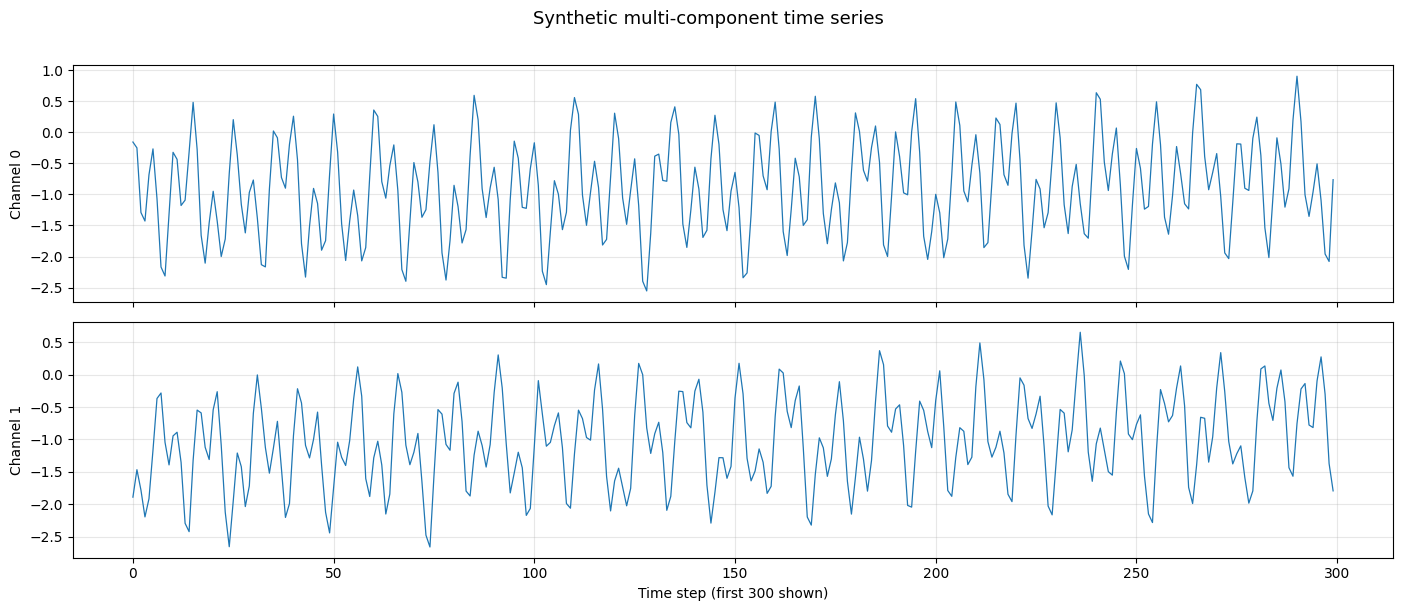

In [2]:
N = 1500          # total time steps
N_CHANNELS = 2    # multivariate channels
SEQ_LEN = 20      # look-back window fed to the model
HORIZON = 5      # forecast horizon

def make_ts(n: int, n_channels: int, seed: int = 0) -> np.ndarray:
    """Return (n, n_channels) float32 array."""
    rng = np.random.default_rng(seed)
    t = np.arange(n, dtype=np.float64)

    channels = []
    angular_freqs = [2 * np.pi / 12, 2 * np.pi / 5, 2 * np.pi / 25]
    for ch in range(n_channels):
        # trend
        trend = 0.002 * t + rng.uniform(-0.5, 0.5)
        # seasonality blend
        a1, a2, a3 = rng.uniform(0.6, 1.2, 3)
        seasonal = (
            a1 * np.sin(angular_freqs[0] * t + rng.uniform(0, 2 * np.pi))
            + a2 * np.cos(angular_freqs[1] * t + rng.uniform(0, 2 * np.pi))
            + 0.3 * a3 * np.sin(angular_freqs[2] * t + rng.uniform(0, 2 * np.pi))
        )
        # short AR(1)
        ar = np.zeros(n)
        phi = rng.uniform(0.55, 0.75)
        for i in range(1, n):
            ar[i] = phi * ar[i - 1] + rng.normal(0, 0.25)
        channels.append(trend + seasonal + 0.4 * ar + rng.normal(0, 0.08, n))

    data = np.stack(channels, axis=1).astype(np.float32)
    # StandardScaler per channel
    data = (data - data.mean(0, keepdims=True)) / (data.std(0, keepdims=True) + 1e-8)
    return data


data = make_ts(N, N_CHANNELS, seed=SEED)
print(f'Series shape: {data.shape}  (should be ({N}, {N_CHANNELS}))')

fig, axes = plt.subplots(N_CHANNELS, 1, figsize=(14, 3 * N_CHANNELS), sharex=True)
for ch, ax in enumerate(axes):
    ax.plot(data[:300, ch], lw=0.9)
    ax.set_ylabel(f'Channel {ch}')
    ax.grid(alpha=0.3)
axes[-1].set_xlabel('Time step (first 300 shown)')
fig.suptitle('Synthetic multi-component time series', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 2  Windowed DataLoaders

In [3]:
def make_windows(
    data: np.ndarray,
    seq_len: int,
    horizon: int,
) -> tuple[torch.Tensor, torch.Tensor]:
    """Sliding-window X/Y pairs.

    X: (n_windows, seq_len, n_channels)
    Y: (n_windows, horizon, n_channels)   — multi-step forecast
    """
    xs, ys = [], []
    end = len(data) - horizon
    for i in range(seq_len, end + 1):
        xs.append(data[i - seq_len : i])
        ys.append(data[i : i + horizon])
    X = torch.tensor(np.stack(xs), dtype=torch.float32)
    Y = torch.tensor(np.stack(ys), dtype=torch.float32)
    return X, Y


X, Y = make_windows(data, SEQ_LEN, HORIZON)
print(f'Windows — X: {X.shape}   Y: {Y.shape}')

n = len(X)
n_train = int(0.70 * n)
n_val   = int(0.15 * n)
n_test  = n - n_train - n_val

X_tr, Y_tr = X[:n_train],          Y[:n_train]
X_va, Y_va = X[n_train:n_train+n_val], Y[n_train:n_train+n_val]
X_te, Y_te = X[n_train+n_val:],    Y[n_train+n_val:]

print(f'Train: {n_train}  Val: {n_val}  Test: {n_test}')

# DARTSTrainer expects (x, y) batches where y has shape (B, horizon, C)
# Keeping (B, H, C) here; the Huber loss averages over all elements.
BATCH = 32
_pin = (DEVICE == "cuda")   # pinned memory enables async CPU→GPU DMA transfers

_cpu_count = os.cpu_count() or 4
if DEVICE == "cuda":
    NUM_WORKERS = min(8, max(2, _cpu_count // 2))
else:
    NUM_WORKERS = min(4, max(1, _cpu_count // 2))

dl_common = dict(
    num_workers=NUM_WORKERS,
    pin_memory=_pin,
    persistent_workers=bool(NUM_WORKERS > 0),
)
if NUM_WORKERS > 0:
    dl_common["prefetch_factor"] = 4

train_loader = DataLoader(
    TensorDataset(X_tr, Y_tr),
    batch_size=BATCH,
    shuffle=True,
    drop_last=True,
    **dl_common,
 )
val_loader   = DataLoader(
    TensorDataset(X_va, Y_va),
    batch_size=BATCH,
    shuffle=False,
    drop_last=False,
    **dl_common,
 )
test_loader  = DataLoader(
    TensorDataset(X_te, Y_te),
    batch_size=BATCH,
    shuffle=False,
    drop_last=False,
    **dl_common,
 )

print(f'Workers: {NUM_WORKERS}  pin_memory: {_pin}')
print(f'Batches per epoch — train: {len(train_loader)}  val: {len(val_loader)}')


Windows — X: torch.Size([1476, 20, 2])   Y: torch.Size([1476, 5, 2])
Train: 1033  Val: 221  Test: 222
Workers: 8  pin_memory: True
Batches per epoch — train: 32  val: 7


## 3  DARTSTrainer setup

We use a compact operation set that covers most interesting inductive biases:

| Op | Inductive bias |
|---|---|
| Identity | skip / residual |
| ResidualMLP | pointwise mixing |
| TimeConv | local temporal patterns |
| TCN | multi-scale dilated convolutions |
| Fourier | global frequency features |
| GRN | gating with context |

> **Mamba note**: `MambaOp` is intentionally excluded from the input/backbone
> cell operations — its causal, autoregressive inductive bias belongs in the
> decoder, not in the shared feature-extraction backbone.  You can still add it
> to the `DARTSTrainer(all_ops=...)` list if you want to experiment.

### Architecture topology (`arch_mode`)

Each candidate model can be built with one of three topologies, which DARTS
now searches over jointly with operation selection:

| `arch_mode` | Description |
|---|---|
| `encoder_decoder` | Full seq2seq: `MixedEncoder` → autoregressive `MixedDecoder` loop (cross-attention bridge enabled) |
| `encoder_only` | Non-autoregressive: `MixedEncoder` → mean-pool → linear forecast head (no decoder, no cross-attention) |
| `decoder_only` | Causal backbone + autoregressive `MixedDecoder` (single-path decode, cross-attention disabled) |

The `arch_modes` list passed to `DARTSTrainer` controls which topologies are
included in the random candidate pool during multi-fidelity search.  Pass a
single-element list to fix the topology and search only over operations/dims.


In [4]:
OPS = [
    'Identity',
    'ResidualMLP',
    'TimeConv',
    'TCN',
    'Fourier',
    'GRN',
]

trainer = DARTSTrainer(
    input_dim=N_CHANNELS,
    hidden_dims=[32, 64],     # smaller dims for a quick demo
    forecast_horizon=HORIZON,
    seq_length=SEQ_LEN,
    device=DEVICE,
    all_ops=OPS,
    # Restrict the search to encoder-decoder models only.
    # To compare other modes later, swap this for a different single-entry list.
    arch_modes=['encoder_decoder'],
)


DARTSTrainer initialised on cuda  [DARTS variant=r_darts]
  input_dim=2  forecast_horizon=5
  operations available: 6
  op families: ['conv', 'frequency', 'mlp']
  arch_modes: ['encoder_decoder']
  attention_variants: ['auto']
  ffn_variants: ['auto']


In [5]:
import torch
from darts.architecture.core_blocks import TimeSeriesDARTS

_seq_len, _horizon, _channels = SEQ_LEN, HORIZON, N_CHANNELS
_x = torch.randn(4, _seq_len, _channels)

# --- quick sanity-check: all three topologies forward-pass cleanly ---
for mode in ('encoder_decoder', 'encoder_only', 'decoder_only'):
    m = TimeSeriesDARTS(
        input_dim=_channels,
        hidden_dim=32,
        latent_dim=32,
        forecast_horizon=_horizon,
        seq_length=_seq_len,
        selected_ops=['Identity', 'TimeConv', 'Fourier'],
        arch_mode=mode,
        op_gdas=True,
        variant_gdas=True,
    )
    m.eval()
    with torch.no_grad():
        y = m(_x)
    print(f"arch_mode={mode!r:20s}  output shape: {tuple(y.shape)}")


arch_mode='encoder_decoder'     output shape: (4, 5, 2)
arch_mode='encoder_only'        output shape: (4, 5, 2)
arch_mode='decoder_only'        output shape: (4, 5, 2)


## 4  Multi-fidelity search

The pipeline runs 5 phases automatically:

1. **Phase 1** — rapid zero-cost scoring of `num_candidates` random architectures
2. **Phase 2** — select `top_k` by aggregate zero-cost score
3. **Phase 3** — short bilevel DARTS training (`search_epochs`) for each top-k model
4. **Phase 4** — pick the best by validation loss, derive the discrete architecture
5. **Phase 5** — full final training (`final_epochs`) from (optionally re-initialised) weights

Adjust `num_candidates`, `search_epochs`, and `final_epochs` to taste — the values below are intentionally small for a fast demo run.

In [6]:
if DEVICE == 'cuda':
    num_candidates = 4
    top_k = 2
    search_epochs = 12
    final_epochs = 30
    max_samples = 16
    max_workers = max(1, min(4, NUM_WORKERS))
else:
    # lighter CPU profile for much faster turnaround
    num_candidates = 2
    top_k = 2
    search_epochs = 8
    final_epochs = 20
    max_samples = 8
    max_workers = max(1, min(2, NUM_WORKERS))

results = trainer.multi_fidelity_search(
    train_loader,
    val_loader,
    test_loader,
    num_candidates=num_candidates,
    top_k=top_k,
    search_epochs=search_epochs,
    final_epochs=final_epochs,
    max_samples=max_samples,
    max_workers=max_workers,
    retrain_final_from_scratch=True,
    discrete_arch_threshold=0.25,
    # AMP halves memory and speeds up ~1.5–2x on CUDA; no-op on CPU
    use_amp=(DEVICE == "cuda"),
)


=== Phase 1: generating + zero-cost evaluating candidates (parallel) ===
Evaluating candidate 0 with config: ['Identity', 'GRN', 'ResidualMLP'], hidden_dim=32, num_cells=1, num_nodes=3, arch_mode=encoder_decoder, families=['mlp'], attn=auto, ffn=auto
Evaluating candidate 1 with config: ['Identity', 'Fourier', 'TCN', 'GRN'], hidden_dim=64, num_cells=2, num_nodes=4, arch_mode=encoder_decoder, families=['frequency', 'conv', 'mlp'], attn=auto, ffn=auto
   Metrics: {'metrics': {'params': 2650192.0, 'conditioning': 3.1219659518100658, 'naswot': 86.22185035044576, 'activation_diversity': 0.0, 'flops': 221364544.0, 'grasp': 0.0, 'fisher': 0.018910003826022148, 'sensitivity': 0.00973762758076191, 'snip': 0.03492343798279762, 'jacobian': 0.0, 'synflow': 0.0}, 'success_rates': {'params': True, 'conditioning': True, 'naswot': True, 'activation_diversity': True, 'flops': True, 'grasp': False, 'fisher': True, 'sensitivity': True, 'snip': True, 'jacobian': False, 'synflow': False}, 'error_messages':

DARTS:  50%|█████     | 1/2 [00:01<00:01,  1.82s/epoch, train=0.0576, val=0.0561, best=0.0561, patience=0/10, conc=10.0]

   [Arch Update] norm: top=1, choice=instance_norm, weight=0.2512, dL1=0.000000
   [Arch Update] encoder_tokenizer_decision: top=5, choice=hierarchical, weight=0.1470, dL1=0.000000
   [Arch Update] encoder_tokenizer_probs: hierarchical=0.1470, direct=0.1461, variate_tokens=0.1422
   [Arch Update] forecast_encoder_self_attention: top=2, choice=probsparse, weight=0.2037, dL1=0.000000
   [Arch Update] encoder_attention_position_decision: top=4, choice=sinusoidal, weight=0.1457, dL1=0.000000
   [Arch Update] encoder_ffn_decision: top=1, choice=geglu, weight=0.2538, dL1=0.000000
   [Arch Update] encoder_ffn_probs: swiglu=0.2472, geglu=0.2538, relu=0.2494, moe=0.2496, selected=geglu
   [Arch Update] informer_decision: top=0, choice=autoregressive, weight=0.3375, dL1=0.000000
   [Arch Update] informer_probs: autoregressive=0.3375, informer=0.3256, selected=autoregressive
   [Arch Update] decoder_query_generator_decision: top=2, choice=learned_horizon_queries, weight=0.2066, dL1=0.000000
   [A

DARTS: 100%|██████████| 2/2 [00:03<00:00,  1.57s/epoch, train=0.0684, val=0.0810, best=0.0561, patience=1/10, conc=10.0]



Training completed in 3.8s
Best Val Loss: 0.056078
MSE: nan | MAE: nan
[P3] completed rung 1 candidate id=1 | mixed_val_loss=0.056078 | train_time=3.809s total=3.809s
[P3] training rung 1 candidate 2/2 (id=0) for +2 epochs | arch_mode=encoder_decoder | families=['mlp'] | attn=auto | ffn=auto
Architecture params: 30, Model params: 288
Training DARTS for 2 epochs
  Arch LR: 0.01, Model LR: 0.001
  Bilevel: True, SWA: False, AMP: True
  Cell edge budget: max_active_edges_per_node=2
  Edge regs: cosine=0.030, usage=0.040, id_cap=0.45@0.020
  MoE balance regularizer: 0.0050
  Transformer exploration regularizer: 0.0100
------------------------------------------------------------


...


Training completed in 5.4s
Best Val Loss: 0.053632
MSE: nan | MAE: nan
[P3] completed rung 4 candidate id=1 | mixed_val_loss=0.053632 | train_time=5.481s total=5.481s
🔧 Deriving final architecture...
   → Fixing Input Normalization: revin (weight: 0.250)
   → Encoder Decomposition: enabled (seasonal_residual, weight: 0.254)
   → Decoder Decomposition: enabled (moving_avg_trend, weight: 0.254)
   Cell 0, Edge 0: IdentityOp (weight: 0.286)
   Cell 0, Edge 1: GRNOp (weight: 0.255)
   Cell 0, Edge 2: TCNOp (weight: 0.589)
   Cell 0, Edge 3: TCNOp (weight: 0.574)
   Cell 0, Edge 4: TCNOp (weight: 0.503)
   Cell 0, Edge 5: GRNOp (weight: 0.265)
   Cell 0: unique ops selected=3, distribution={'TCN': 3, 'Identity': 1, 'GRN': 2}
   Cell 1, Edge 0: TCNOp (weight: 0.375)
   Cell 1, Edge 1: TCNOp (weight: 0.524)
   Cell 1, Edge 2: IdentityOp (weight: 0.320)
   Cell 1, Edge 3: GRNOp (weight: 0.313)
   Cell 1, Edge 4: TCNOp (weight: 0.479)
   Cell 1, Edge 5: GRNOp (weight: 0.262)
   Cell 1: unique 

Early stop @ epoch 28:  90%|█████████ | 27/30 [01:08<00:07,  2.53s/epoch, train=0.0060, val=0.0104, best_val=0.0103, patience=5/6]



Evaluating on test set...


Test Evaluation: 100%|██████████| 7/7 [00:00<00:00, 17.37batch/s, test_loss=0.0086]


Training curve saved to final_model_training.pdf


## 5  Inspect results

In [7]:
best = results['best_candidate']
final = results['final_results']
final_model = results['final_model']

def _patching_mode(model_obj, role):
    component = getattr(model_obj, f'forecast_{role}', None)
    if component is None:
        return 'not used'
    submodule = getattr(component, 'rnn', None)
    if submodule is None:
        submodule = getattr(component, 'transformer', None)
    if submodule is None:
        return 'unknown'
    direct = getattr(submodule, 'patching_mode', None)
    if isinstance(direct, str) and direct and direct != 'auto':
        return direct
    resolver = getattr(submodule, 'resolve_patch_mode', None)
    if callable(resolver):
        try:
            return str(resolver())
        except Exception:
            pass
    logits = getattr(submodule, 'patch_alpha_logits', None)
    mode_names = getattr(submodule, 'patch_mode_names', ())
    if isinstance(logits, torch.Tensor) and logits.numel() == len(mode_names):
        probs = torch.softmax(logits.detach(), dim=0)
        top_idx = int(torch.argmax(probs).item())
        if 0 <= top_idx < len(mode_names):
            return str(mode_names[top_idx])
    return 'unknown'

encoder_patch = _patching_mode(final_model, 'encoder')
decoder_patch = _patching_mode(final_model, 'decoder')

print('=== Best candidate ===')
print(f"  Search pipeline : multi-fidelity")
print(f"  Patching        : encoder={encoder_patch} | decoder={decoder_patch}")
print(f"  Zero-cost score : {best['candidate']['score']:.4f}")
print(f"  Selected ops    : {best['candidate'].get('selected_ops', 'N/A')}")
print(f"  Hidden dim      : {best['candidate'].get('hidden_dim')}")
print(f"  Val loss (derived): {best['val_loss']:.6f}")

print('\n=== Final model ===')
# print(f"  Best val loss   : {final['best_val_loss']:.6f}")
fm = final.get('final_metrics', {})
for k, v in fm.items():
    print(f"  {k:20s}: {v:.6f}")

=== Best candidate ===
  Search pipeline : multi-fidelity
  Patching        : encoder=hierarchical | decoder=unknown
  Zero-cost score : 0.8984
  Selected ops    : ['Identity', 'Fourier', 'TCN', 'GRN']
  Hidden dim      : 64
  Val loss (derived): 0.052476

=== Final model ===
  mse                 : 0.029366
  rmse                : 0.171365
  mae                 : 0.136223
  mape                : 47.734132
  r2_score            : 0.944446


## 5.1  Selected transformer architecture

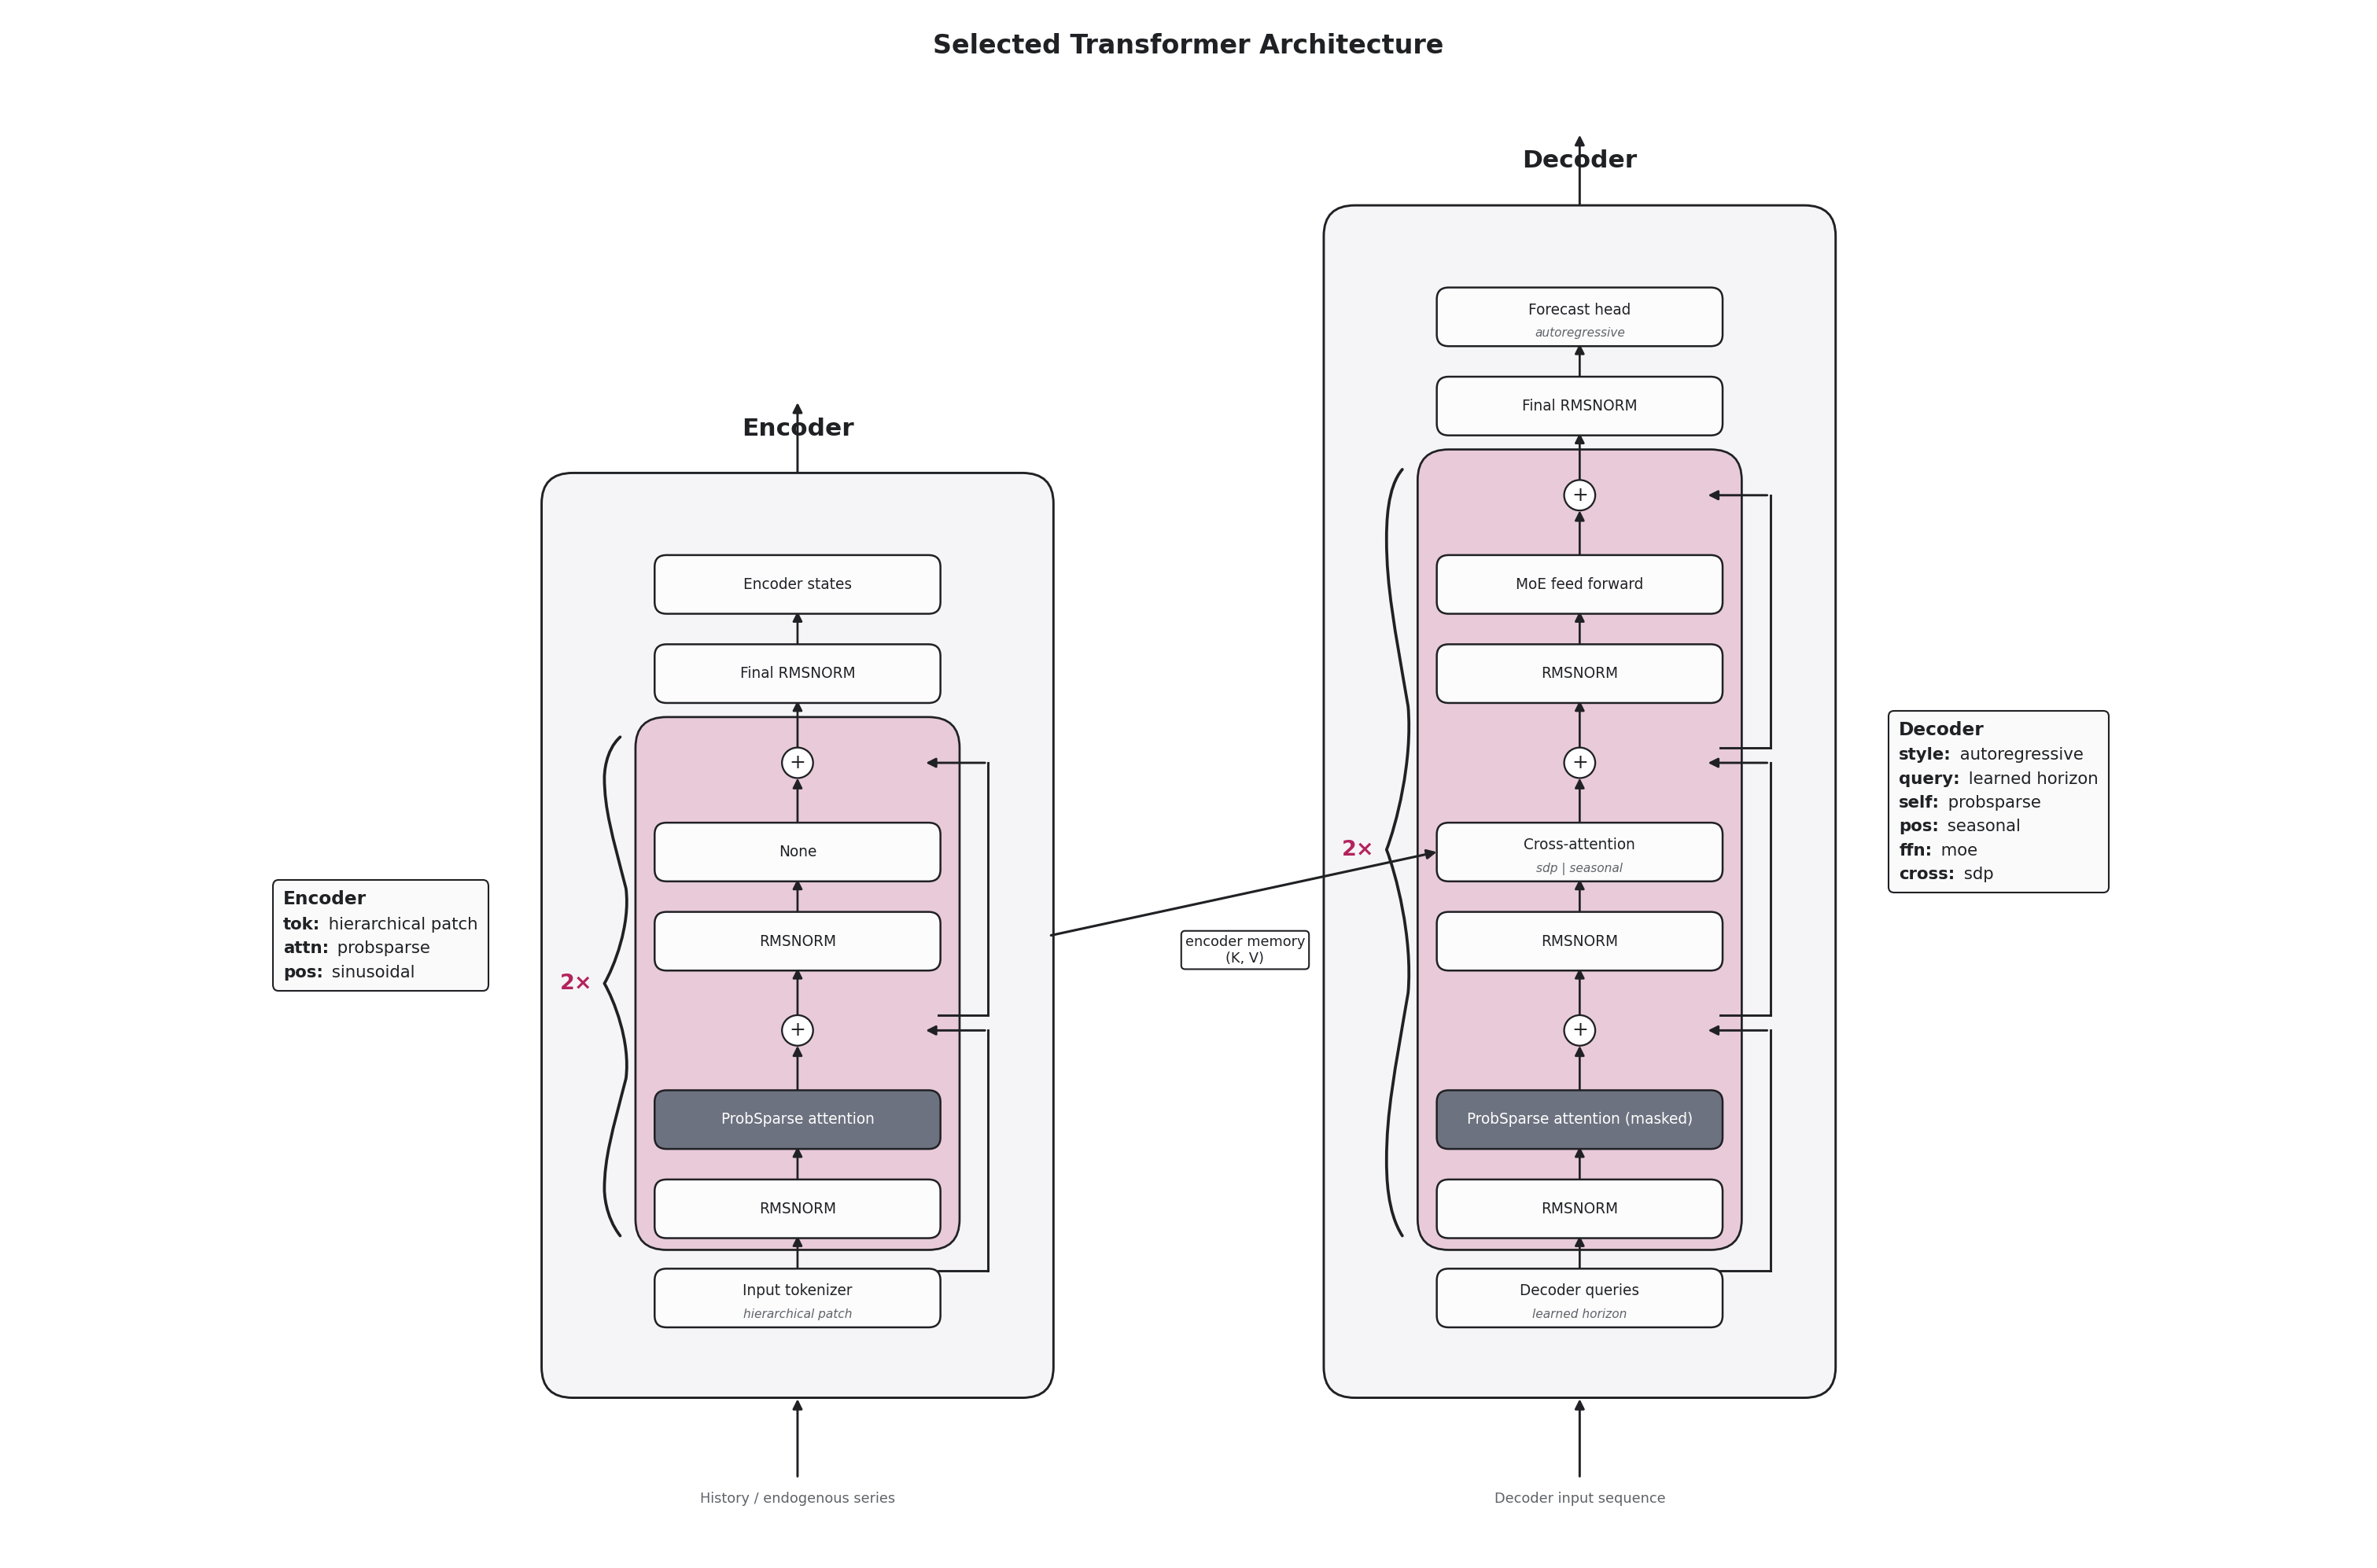

In [8]:
from darts.transformer_diagram import draw_selected_transformer_architecture

final_model = results['final_model']
fig, ax = draw_selected_transformer_architecture(
    final_model,
    title='Selected Transformer Architecture',
)
plt.show()

# Optional: save a copy next to the notebook.
# fig.savefig('selected_transformer_architecture.png', dpi=160, bbox_inches='tight')


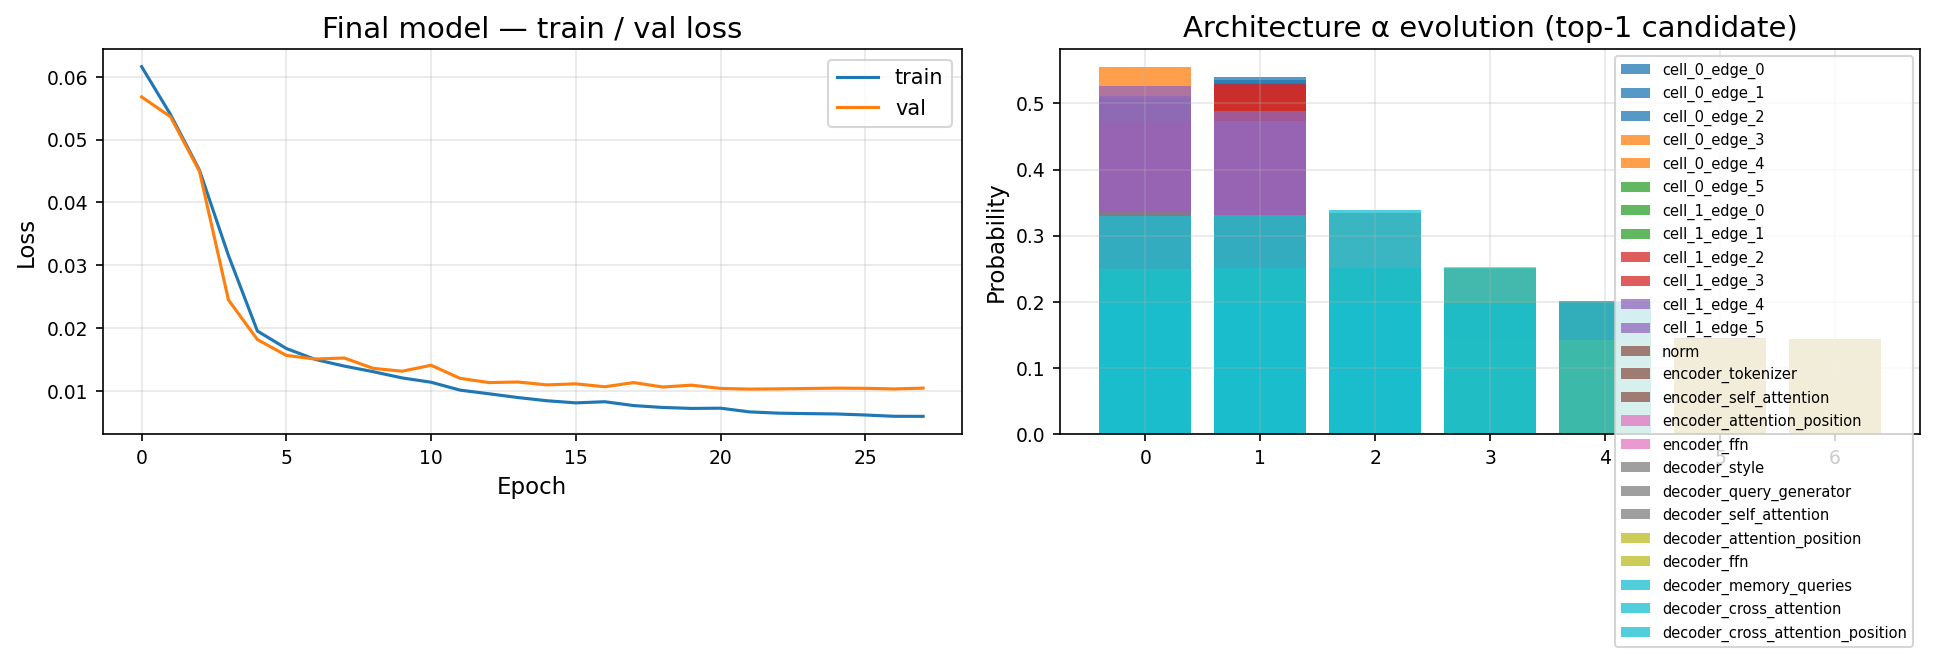

In [9]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].set_title('Final model — train / val loss')
axes[0].plot(final['train_losses'], label='train')
axes[0].plot(final['val_losses'],   label='val')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# α evolution for the best search candidate (phase-3 results)
alpha_values = results['trained_candidates'][0]['search_results']['alpha_values']
if alpha_values:
    axes[1].set_title('Architecture α evolution (top-1 candidate)')
    snap = alpha_values[-1]  # last snapshot
    names  = [s[0] for s in snap]
    probs  = [s[1] for s in snap]
    n_alphas = len(names)
    cmap = plt.cm.get_cmap('tab10', n_alphas)
    for i, (nm, pr) in enumerate(zip(names, probs)):
        axes[1].bar(range(len(pr)), pr, label=nm, alpha=0.75, color=cmap(i))
    axes[1].set_xticks(range(max(len(p) for p in probs)))
    axes[1].set_ylabel('Probability')
    axes[1].legend(fontsize=7, loc='upper right')
    axes[1].grid(alpha=0.3)
else:
    axes[1].text(0.5, 0.5, 'No α snapshots recorded', ha='center', va='center')
    axes[1].set_axis_off()

plt.tight_layout()
plt.show()

## 6  Qualitative forecast check

Roll the final model over the test set and plot predicted vs actual for one channel.

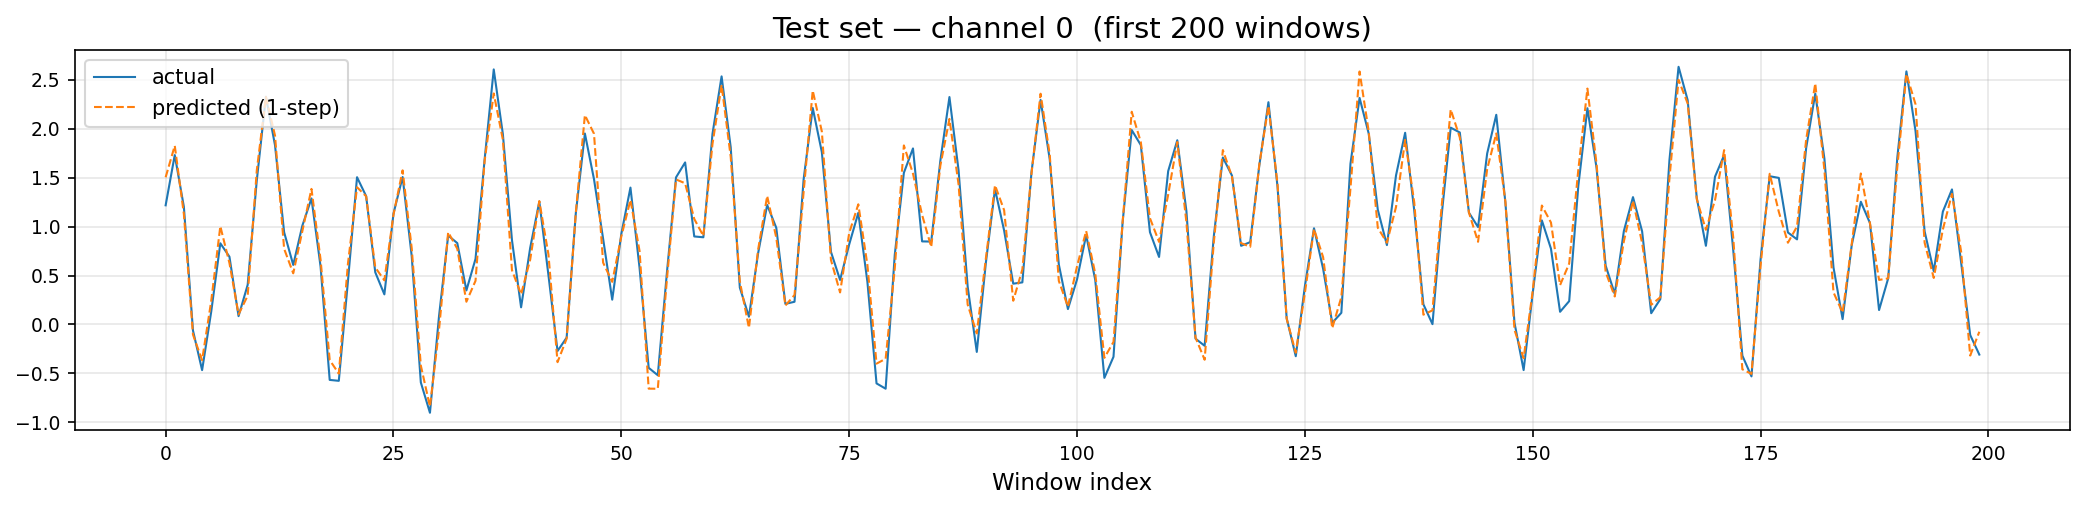

Test MSE (1-step, ch. 0): 0.02038   MAE: 0.11415


In [10]:
final_model = results['final_model']
final_model.eval()

preds_list, actuals_list = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)
        out = final_model(xb).cpu().numpy()  # (B, H, C) or (B, H*C)
        preds_list.append(out)
        actuals_list.append(yb.numpy())

preds   = np.concatenate(preds_list,   axis=0)  # (N_test, ...)
actuals = np.concatenate(actuals_list, axis=0)

# Reshape if model returns flat output
if preds.ndim == 2 and preds.shape[1] == HORIZON * N_CHANNELS:
    preds   = preds.reshape(-1, HORIZON, N_CHANNELS)
    actuals = actuals.reshape(-1, HORIZON, N_CHANNELS)

# Plot the 1-step-ahead prediction for channel 0
CH = 0
pred_1step   = preds[:, 0, CH]
actual_1step = actuals[:, 0, CH]

T_show = min(200, len(pred_1step))
fig, ax = plt.subplots(figsize=(14, 3.5))
ax.plot(actual_1step[:T_show], lw=1.0, label='actual')
ax.plot(pred_1step[:T_show],   lw=1.0, linestyle='--', label='predicted (1-step)')
ax.set_title(f'Test set — channel {CH}  (first {T_show} windows)')
ax.set_xlabel('Window index')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

mse  = float(np.mean((pred_1step - actual_1step) ** 2))
mae  = float(np.mean(np.abs(pred_1step - actual_1step)))
print(f'Test MSE (1-step, ch. {CH}): {mse:.5f}   MAE: {mae:.5f}')

## 7  Discrete architecture summary

In [11]:
def _patching_mode(model_obj, role):
    component = getattr(model_obj, f'forecast_{role}', None)
    if component is None:
        return 'not used'
    submodule = getattr(component, 'rnn', None)
    if submodule is None:
        submodule = getattr(component, 'transformer', None)
    if submodule is None:
        return 'unknown'
    direct = getattr(submodule, 'patching_mode', None)
    if isinstance(direct, str) and direct and direct != 'auto':
        return direct
    resolver = getattr(submodule, 'resolve_patch_mode', None)
    if callable(resolver):
        try:
            return str(resolver())
        except Exception:
            pass
    logits = getattr(submodule, 'patch_alpha_logits', None)
    mode_names = getattr(submodule, 'patch_mode_names', ())
    if isinstance(logits, torch.Tensor) and logits.numel() == len(mode_names):
        probs = torch.softmax(logits.detach(), dim=0)
        top_idx = int(torch.argmax(probs).item())
        if 0 <= top_idx < len(mode_names):
            return str(mode_names[top_idx])
    return 'unknown'

print('Patching summary:')
print(f"  encoder: {_patching_mode(final_model, 'encoder')}")
print(f"  decoder: {_patching_mode(final_model, 'decoder')}")

if hasattr(final_model, 'derive_discrete_architecture'):
    discrete = final_model.derive_discrete_architecture(threshold=0.25)
    print('Discrete architecture:')
    for k, v in discrete.items():
        print(f'  {k}: {v}')
else:
    # Fall back to alpha inspection via trainer's AlphaTracker
    print('Alpha probabilities at convergence:')
    final_model.eval()
    with torch.no_grad():
        for name, probs in trainer.alpha_tracker.extract_alpha_values(final_model):
            top_idx = int(np.argmax(probs))
            print(f'  {name}: top_idx={top_idx}  probs={np.round(probs, 3)}')

Patching summary:
  encoder: hierarchical
  decoder: unknown
Discrete architecture:
  norm: {'type': 'revin', 'weight': 1.0, 'passed_threshold': True}
  encoder: {'type': 'transformer', 'weight': 1.0, 'passed_threshold': True}
  decoder: {'type': 'transformer', 'weight': 1.0, 'passed_threshold': True}


In [12]:
# Timing summary across phases
stats = results.get('stats', {})
phase_summary = stats.get('phase_summary', {})
if phase_summary:
    print('Wall-clock time per phase:')
    total = 0.0
    for ph, info in phase_summary.items():
        t = info.get('wall_time_sec', 0.0)
        total += t if ph != 'total' else 0.0
        print(f'  {ph:10s}: {t:.2f}s')
    print(f'  {"TOTAL":10s}: {total:.2f}s')
else:
    import time as _time
    print('(stats not collected; pass collect_stats=True to capture timing)')

(stats not collected; pass collect_stats=True to capture timing)
